#**ONE G9 - CHALLENGE ALURA STORE**

##**Descripción**

Durante este desafío, ayudarás al Sr. Juan a decidir qué tienda de su cadena Alura Store debe vender para iniciar un nuevo emprendimiento. Para ello, analizarás datos de ventas, rendimiento y reseñas de las 4 tiendas de Alura Store. El objetivo es identificar la tienda menos eficiente y presentar una recomendación final basada en los datos.

Lo que practicarás:

Cargue y manipule datos CSV con la biblioteca Pandas.

Cree visualizaciones de datos con la biblioteca Matplotlib.

Analice métricas como ingresos, reseñas y rendimiento de ventas.

Requisitos:

Analizar datos de la tienda:

Debes evaluar información como los ingresos, las categorías más vendidas, las reseñas de los clientes, los productos más vendidos y el envío promedio.



Crear gráficos para visualización:

Decide qué tipos de gráficos utilizar para presentar los resultados de forma clara y visual.

Mínimo de 3 gráficos diferentes, que pueden incluir gráficos de barras, circulares, de dispersión y otros.



Enviar una recomendación:

Después del análisis, escriba un texto explicando a qué tienda debería vender el Sr. João y por qué, basándose en los datos presentados.



##**Importación de datos**

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()



,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


##**Generación de Data Frame**

In [5]:
#Se combinan las tablas

tienda['tiendas']='tienda1'
tienda2['tiendas']='tienda2'
tienda3['tiendas']='tienda3'
tienda4['tiendas']='tienda4'

#Se agrupan y se suman

df_total = pd.concat([tienda,tienda2,tienda3,tienda4])
df_total.sample(5)



,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon,tiendas
512,Mochila,Deportes y diversión,107100.0,8100.0,25/04/2022,Izabela de León,Pereira,5,Nequi,1,4.81333,-75.69611,tienda1
1890,Tablet ABXY,Electrónicos,1231700.0,63800.0,01/05/2022,Lucas Olivera,Bogotá,4,Tarjeta de crédito,6,4.60971,-74.08175,tienda1
2060,Cuerda para saltar,Deportes y diversión,9300.0,0.0,06/11/2020,Camila Rivera,Bogotá,5,Nequi,1,4.60971,-74.08175,tienda4
807,Celular ABXY,Electrónicos,988100.0,52800.0,27/02/2022,Lucas Olivera,Santa Marta,4,Tarjeta de crédito,4,11.24079,-74.19904,tienda3
2100,Modelado predictivo,Libros,48200.0,800.0,29/10/2022,Ángel Rodriguez,Cali,5,Cupón,1,3.43722,-76.52250,tienda2


##**1. Ingreso total por tienda**

En este primer análisis, se calculará el ingreso total de cada tienda. Sumando los valores de la columna Precio de cada conjunto de datos de la tienda para estimar los ingresos.


In [6]:
ingreso_por_tienda = df_total.groupby('tiendas')['Precio'].sum()
ingreso_formateado = ingreso_por_tienda.map('${:,.0f}'.format)

Porcentaje_de_ventas_por_tienda = (ingreso_por_tienda / ingreso_por_tienda.sum()) * 100
porcentaje_formateado = Porcentaje_de_ventas_por_tienda.map('{:.1f}%'.format)

print(ingreso_formateado)
print(' ')
print(porcentaje_formateado)


tiendas
tienda1    $1,150,880,400
tienda2    $1,116,343,500
tienda3    $1,098,019,600
tienda4    $1,038,375,700
Name: Precio, dtype: object
 
tiendas
tienda1    26.1%
tienda2    25.4%
tienda3    24.9%
tienda4    23.6%
Name: Precio, dtype: object


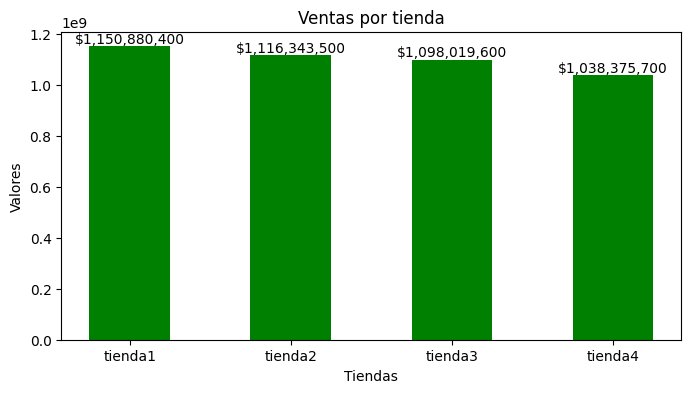

In [38]:
#Se grafica el ingreso total por tienda

from matplotlib import pyplot as plt

x=ingreso_por_tienda.index
y=ingreso_por_tienda.values

plt.figure(figsize=(8,4))
plt.bar(x,y,width=0.5,color='green')

plt.xlabel('Tiendas')
plt.ylabel('Valores')
plt.title('Ventas por tienda')

for i, v in enumerate(y):
    plt.text(i, v, f'${v:,.0f}', ha='center', va='bottom')

#plt.savefig('/content/drive/MyDrive/Colab Notebooks/ONE_G9/CH1/1_ventasXtienda.png') #Guardar imagen
plt.show()

##**2. Ventas por categoría**

Calcular la cantidad de productos vendidos por categoría en cada tienda. El objetivo es agrupar los datos por categoría y contar el número de ventas de cada tipo, mostrando las categorías más populares de cada tienda.




In [11]:
#Cantidad de productos vendidos por cada categoría
ventas_por_tienda_cat = df_total.groupby(['tiendas', 'Categoría del Producto']).size().reset_index(name='Cantidad_Vendida')
ventas_ordenadas = ventas_por_tienda_cat.sort_values(by=['tiendas','Cantidad_Vendida'], ascending=[True,False])
print('Cantidad de productos vendidos por categoría en cada tienda')
print(ventas_ordenadas)
print(' ')

#Categorías mas polulares de cada tienda
idx_max = ventas_ordenadas.groupby('tiendas')['Cantidad_Vendida'].idxmax()
Cat_mas_vendidos_por_tienda = ventas_ordenadas.loc[idx_max]
print('Categorías más populares de cada tienda')
print(Cat_mas_vendidos_por_tienda)


Cantidad de productos vendidos por categoría en cada tienda
    tiendas   Categoría del Producto  Cantidad_Vendida
7   tienda1                  Muebles               465
3   tienda1             Electrónicos               448
5   tienda1                 Juguetes               324
2   tienda1        Electrodomésticos               312
1   tienda1     Deportes y diversión               284
4   tienda1   Instrumentos musicales               182
6   tienda1                   Libros               173
0   tienda1  Artículos para el hogar               171
15  tienda2                  Muebles               442
11  tienda2             Electrónicos               422
13  tienda2                 Juguetes               313
10  tienda2        Electrodomésticos               305
9   tienda2     Deportes y diversión               275
12  tienda2   Instrumentos musicales               224
14  tienda2                   Libros               197
8   tienda2  Artículos para el hogar               181
23  t

##**3. Valoración media por tienda**

En este paso, debes calcular las calificaciones promedio de los clientes para cada tienda. El objetivo es conocer la satisfacción del cliente con los productos vendidos.



In [12]:
Calificacion_prom_por_tienda = df_total.groupby('tiendas')['Calificación'].mean()
Redondeado = round(Calificacion_prom_por_tienda,3)
print(Redondeado)

tiendas
tienda1    3.977
tienda2    4.037
tienda3    4.048
tienda4    3.996
Name: Calificación, dtype: float64


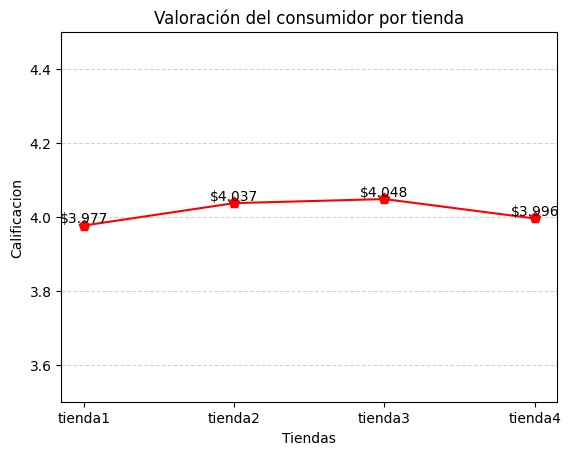

In [39]:
#Se grafica la valoracion media por tienda

from matplotlib import pyplot as plt

x = Calificacion_prom_por_tienda.index
y = Calificacion_prom_por_tienda.values

plt.xlabel('Tiendas')
plt.ylabel('Calificacion')
plt.title('Valoración del consumidor por tienda')

plt.ylim(ymin=3.5, ymax=4.5)

plt.grid(color="lightgray",linestyle="--", axis="y")
plt.plot(x,y, marker='p', markersize=8, color='red' )


for i, v in enumerate(y):
    plt.text(i, v, f'${v:,.3f}', ha='center', va='bottom')

#plt.savefig('/content/drive/MyDrive/Colab Notebooks/ONE_G9/CH1/2_valoracionXtienda.png') #Guardar imagen
plt.show()

##**4. Productos más vendidos y menos vendidos**

En este paso, debes identificar qué productos fueron los más vendidos y los menos vendidos en cada tienda. Visualiza los resultados para que quede claro qué productos destacaron en ventas en cada tienda.

In [14]:
ventas_por_tienda_producto = df_total.groupby(['tiendas', 'Producto']).size().reset_index(name='Cantidad_Vendida')

# Encuentra el producto más vendido para cada tienda
idx_max = ventas_por_tienda_producto.groupby('tiendas')['Cantidad_Vendida'].idxmax()
productos_mas_vendidos_por_tienda = ventas_por_tienda_producto.loc[idx_max]
print("Productos más vendidos por tienda:")
print(productos_mas_vendidos_por_tienda)
print(' ')

# Encuentra el producto menos vendido para cada tienda
idx_min = ventas_por_tienda_producto.groupby('tiendas')['Cantidad_Vendida'].idxmin()
productos_menos_vendidos_por_tienda = ventas_por_tienda_producto.loc[idx_min]
print("Productos menos vendidos por tienda:")
print(productos_menos_vendidos_por_tienda)

Productos más vendidos por tienda:
     tiendas                   Producto  Cantidad_Vendida
1    tienda1                    Armario                60
75   tienda2  Iniciando en programación                65
129  tienda3              Kit de bancas                57
163  tienda4                   Cama box                62
 
Productos menos vendidos por tienda:
     tiendas                   Producto  Cantidad_Vendida
4    tienda1  Auriculares con micrófono                33
77   tienda2              Juego de mesa                32
111  tienda3    Bloques de construcción                35
175  tienda4         Guitarra eléctrica                33


##**5. Valor promedio de envío por tienda**

En este paso, debes calcular el costo de envío promedio para cada tienda. El objetivo es comprender cuánto se gasta, en promedio, en el envío de cada tienda.  Sabiendo que el cliente paga el envío.

In [15]:
Cost_prom_de_envio = df_total.groupby('tiendas')['Costo de envío'].mean()
print(Cost_prom_de_envio)

tiendas
tienda1    26018.609580
tienda2    25216.235693
tienda3    24805.680373
tienda4    23459.457167
Name: Costo de envío, dtype: float64


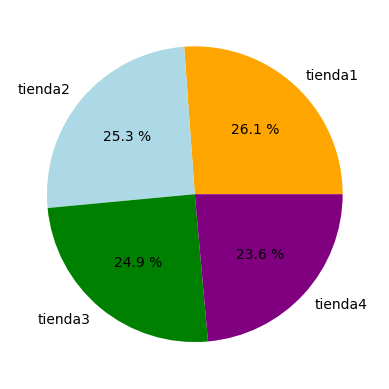

In [40]:
#Se grafica el valor promedio de envío por tienda

from matplotlib import pyplot as plt

A = Cost_prom_de_envio.index
B = Cost_prom_de_envio.values
c = ['orange','lightblue','green','purple']

plt.pie(B, labels=A, colors=c, autopct="%0.1f %%")

#plt.savefig('/content/drive/MyDrive/Colab Notebooks/ONE_G9/CH1/3_envioXtienda.png') #Guardar imagen
plt.show()

##**6. Última fecha de compra por tienda**

In [18]:
df_total['Fecha de Compra'] = pd.to_datetime(df_total['Fecha de Compra'])
ultima_venta_por_tienda = df_total.groupby('tiendas')['Fecha de Compra'].max()
print(ultima_venta_por_tienda)
print(' ')

tiendas
tienda1   2023-03-31
tienda2   2023-03-31
tienda3   2023-03-31
tienda4   2023-03-30
Name: Fecha de Compra, dtype: datetime64[ns]
 


/tmp/ipython-input-188/2991086489.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_total['Fecha de Compra'] = pd.to_datetime(df_total['Fecha de Compra'])


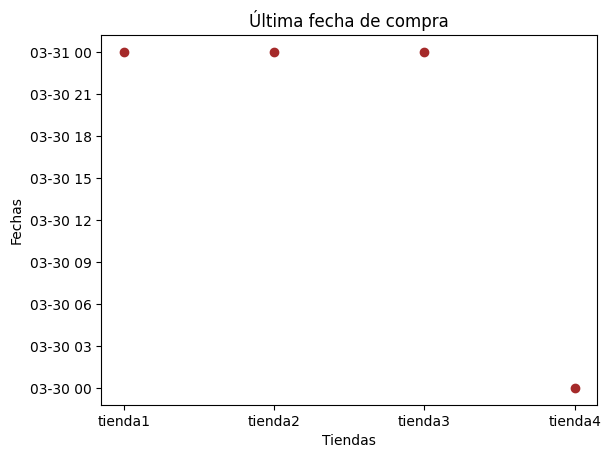

In [41]:
#Se grafica la última fecha de compra por tienda

from matplotlib import pyplot as plt
x = ultima_venta_por_tienda.index
y = ultima_venta_por_tienda.values
fig, ax = plt.subplots()

ax.scatter(x, y, color='brown')
ax.set_xlabel('Tiendas')
ax.set_ylabel('Fechas')
plt.title('Última fecha de compra')

#plt.savefig('/content/drive/MyDrive/Colab Notebooks/ONE_G9/CH1/4_ultcompraXtienda.png') #Guardar imagen
plt.show()

##**Extra: Análisis de geolocalización**

Este análisis busca explorar las coordenadas geográficas de los datos de ventas e identificar patrones relacionados con la ubicación de las compras.

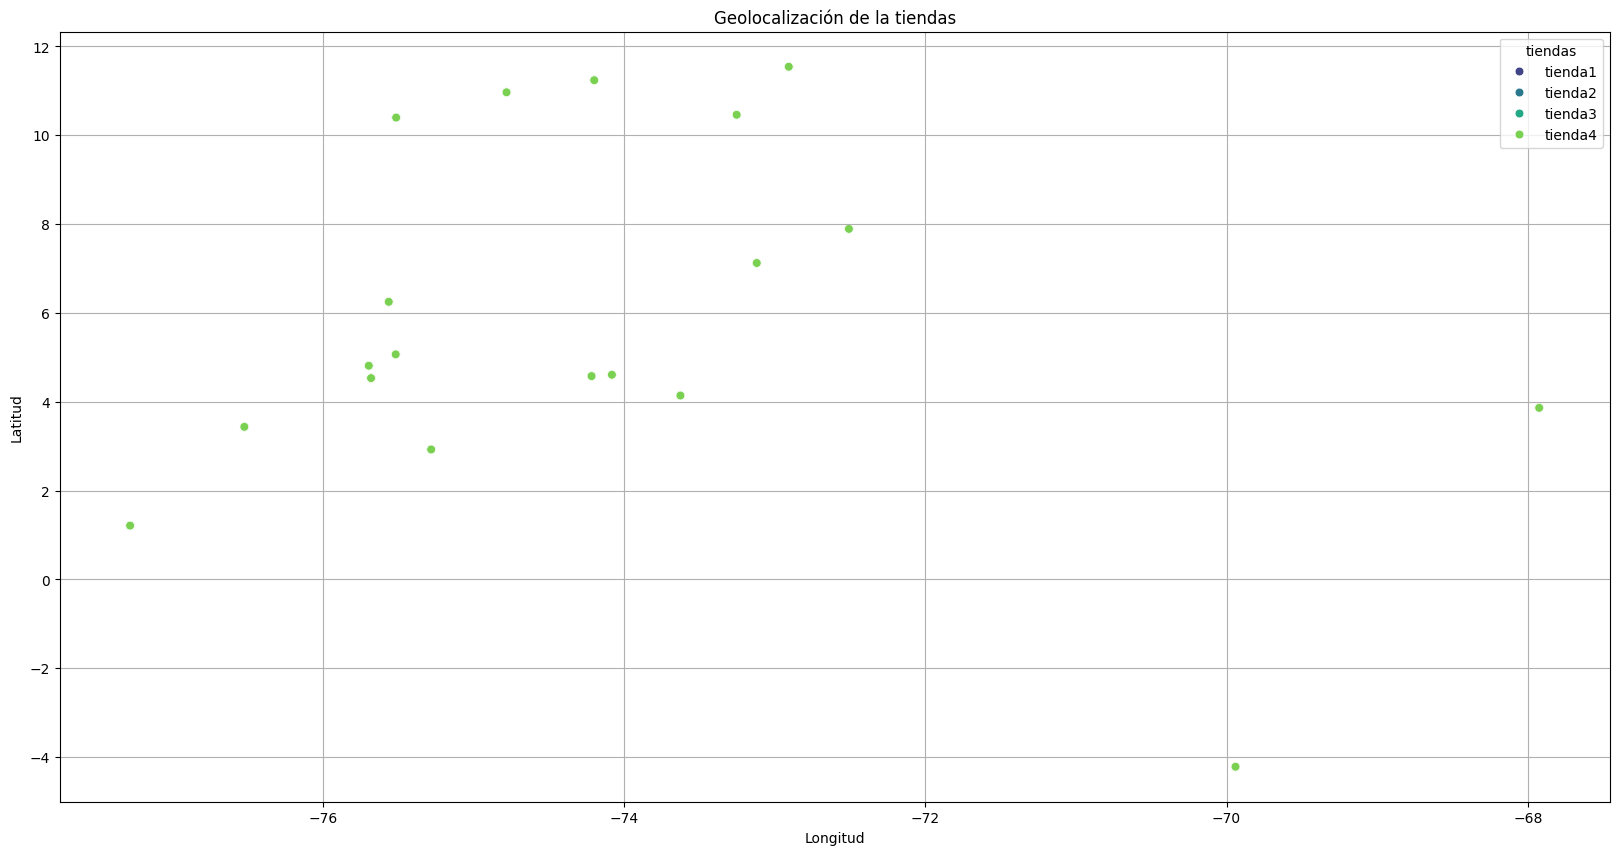

Rendimiento Por Tienda
tiendas
tienda1    $1,150,854,381
tienda2    $1,116,318,284
tienda3    $1,097,994,794
tienda4    $1,038,352,241
dtype: object
 


In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

#Localización
plt.figure(figsize=(20,10))
sns.scatterplot(x='lon', y='lat', data=df_total, hue='tiendas', palette='viridis',s=40)

plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.title('Geolocalización de la tiendas')
plt.legend(title='tiendas',loc='upper right')
plt.grid(True)
#plt.savefig('/content/drive/MyDrive/Colab Notebooks/ONE_G9/CH1/5_geolocalizacionVentas.png') #Guardar imagen
plt.show()

#Rendimiento
Rendimiento = ingreso_por_tienda - Cost_prom_de_envio
Rendimiento_formateado = Rendimiento.map('${:,.0f}'.format)
print ('Rendimiento Por Tienda')
print (Rendimiento_formateado)
print (' ')

#**INFORME DE RESULTADOS**

Con base en el análisis de los datos de las 4 tiendas de la cadena Alura Store, el cual se centró en:

*   Ingresos totales por tienda.
*   Categorías de productos más y menos vendidas.
*   Calificación promedio de los clientes por tienda.
*   Productos más y menos vendidos.
*   Coste de envío promedio para cada tienda.

Se detalla lo siguiente:

1. Derivado del análisis de los ingresos totales de la cadena, se tiene que la tienda que registró el **menor ingreso es la tienda 4**, representando un **23,6% del total**. En cambio, la **tienda 1** representó el **26,1%** de los ingresos totales, siendo la que reportó el mayor ingreso en la cadena.

En el siguiente gráfico se detalla el aporte de cada tienda a los ingresos de la cadena Alura Store.

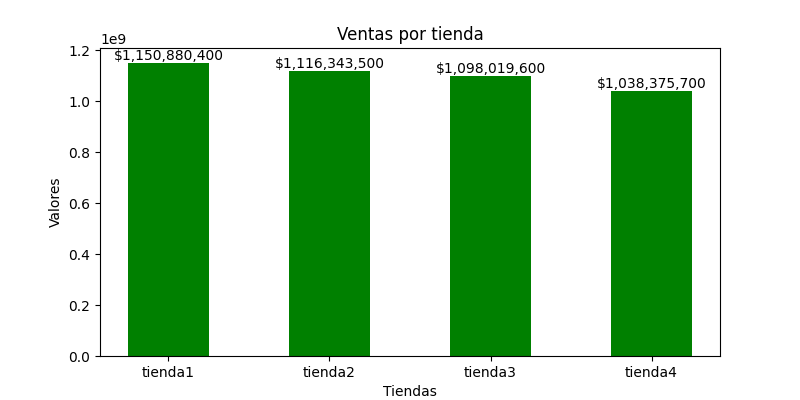



2. Al evaluar la opinión de los consumidores respecto a las tiendas, es similar para cada una de ellas: tienda 1 (3.97 puntos), tienda 4 (3.99 puntos), tienda 2 (4.03 puntos), tienda 3 (4.04 puntos). Se destaca que la **tienda 4 es la penúltima** en esta clasificación.

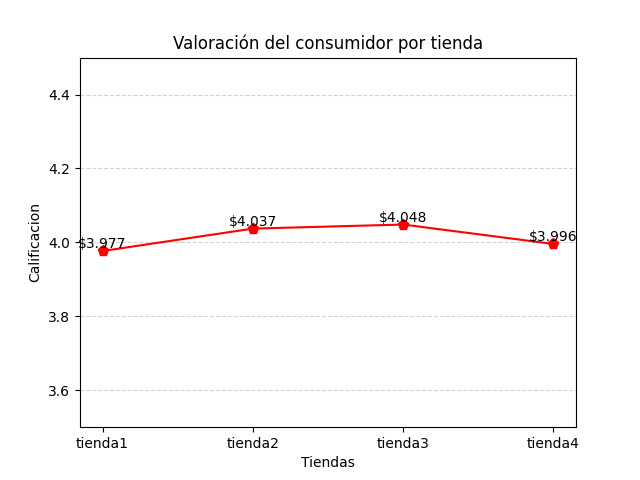



3. En lo que se refiere a las **ventas por categorías en todas las tiendas**, la de mayor venta son los **Muebles**, siendo en la **tienda 3** donde más se venden estos artículos.

Sin embargo, la categoría que representa mayores ventas es distinta en cada tienda: en la que se tienen los mayores ingresos (**tienda 1**) son los **Armarios**, en la **tienda 2** lo es **Iniciando en programación**, mientras que en la **tienda 3** son los **Kit de bancas**.



4. Por último, respecto a los **costos de envío**, la **tienda 4 presenta los costos más bajos**. Aún con esto, y como se mencionó en los puntos anteriores, no cuenta con las mejores opiniones de los consumidores y representa las menores ventas de la cadena Alura Store.

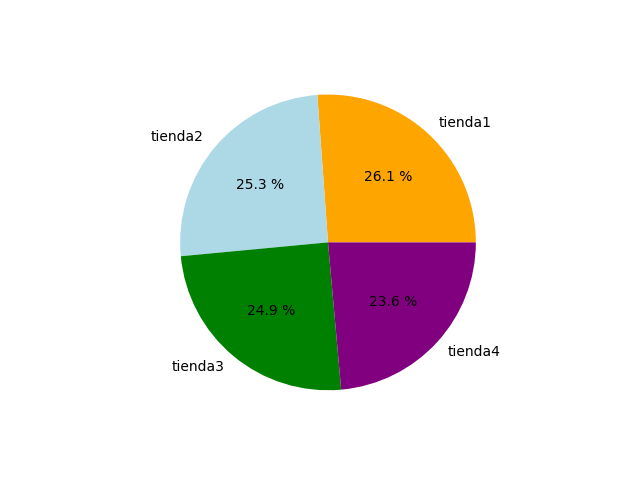



##**Conclusión.**

A partir del análisis presentado, se observa que la tienda con menor desempeño es la tienda 4, dado que es la que presenta el menor ingreso por ventas, aún contando con el costo de envío más bajo; además se sitúa como la penúltima en cuanto a la valoración del consumidor. También se tiene el registro de un día con 0 (cero) ventas, por lo que se debe analizar la razón de esta situación y si se podría presentar nuevamente en un futuro, ya que puede representar un impacto significativo en las finanzas de la cadena Alura Store.

Por lo tanto, **es factible considerar la venta de la sucursal de Alura Store identificada como tienda 4**.


In [43]:
#Activar para guardar las imágenes en carpeta de Drive
#from google.colab import drive
#drive.mount('/content/drive')